# Simple Event Log Analysis
#### Task:
Report basic event log statistics in a table, inclunding:
- number of cases
- number of events
- number of offers
- number of process variants
- number of process variants to cover 80% of cases 
- number of distinct case and event attribute labels 
- mean and standard deviation of case length
- mean and standard deviation of case duration
-  number of categorical event attributes
 

#### Import relevant libraries

In [1]:
import pm4py # process mining library
import pandas as pd # data manipulation library
import os # operating system library for file handling
import matplotlib.pyplot as plt # plotting library for visualizations
import numpy as np # numerical computing library for data analysis

**load log**

In [5]:
raw_log = pm4py.read_xes("../data/BPIChallenge2017.xes.gz")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

#### define analysis function:
- number of cases
- number of events
- number of offers
- number of process variants
- number of process variants to cover 80% of cases 
- mean and standard deviation of case length
- mean and standard deviation of case duration

In [47]:
def get_event_log_info(log):
    try:
        # Calculate basic statistics about the event log
        num_cases = log['case:concept:name'].nunique()
        num_events = log['EventID'].nunique()
        num_offers = log['OfferID'].nunique()

        # Calculate the number of unique process variants
        num_process_variants = len(pm4py.get_variants(log))

        # Calculate coverage of the most common process variant
        variants = pm4py.get_variants(log)
        variant_counts = pd.Series(variants).sort_values(ascending=False)
        variant_coverage = variant_counts.cumsum() / variant_counts.sum()
        num_variants_covered_80_percent = (variant_coverage <= 0.8).sum() + 1  # +1 to include the variant that reaches 80%

        # Get length of each case == number of events per case
        len_cases = log.groupby('case:concept:name').size()
        mean_case_length = len_cases.mean()
        std_case_length = len_cases.std()

        duration_cases = pm4py.stats.get_all_case_durations(log)
        mean_case_duration = np.mean(duration_cases)
        std_case_duration = np.std(duration_cases)

        def format_duration(seconds):
            if seconds < 60:
                return f"{seconds:.2f} seconds"
            elif seconds < 3600:
                return f"{seconds / 60:.2f} minutes"
            elif seconds < 86400:
                return f"{seconds / 3600:.2f} hours"
            else:
                return f"{seconds / 86400:.2f} days"

        stats = pd.DataFrame({
            'Metric': [
                'Number of cases',
                'Number of events',
                'Number of offers',
                'Number of process variants',
                'Number of variants covering 80% of cases',
                'Mean case length',
                'Std case length',
                'Mean case duration',
                'Std case duration',
            ],
            'Value': [
                num_cases,
                num_events,
                num_offers,
                num_process_variants,
                num_variants_covered_80_percent,
                mean_case_length,
                std_case_length,
                format_duration(mean_case_duration),
                format_duration(std_case_duration)
            ]
        }).set_index('Metric')

        return stats

    except Exception as e:
        print(f"Error processing event log: {e}")
        return None

#### define analysis function:
*(automatic interpretation)*
- distinct case and attribute labels
-  number of categorical event attributes

In [48]:
def get_attributes(log):
    try:
        case_attr_labels = [col for col in log.columns if col.startswith('case:')]
        event_attr_labels = [col for col in log.columns if not col.startswith('case:')]

        num_case_attr_labels = len(case_attr_labels)
        num_event_attr_labels = len(event_attr_labels)

        event_cols = [col for col in log.columns if not col.startswith('case:')]
        num_categorical_event_attrs = sum(log[col].dtype in ('object', 'category') for col in event_cols)
        stats = pd.DataFrame({
            'Metric': [
                'Number of case attribute labels',
                'Number of event attribute labels',
                'Number of categorical event attributes'
            ],
            'Value': [
                num_case_attr_labels,
                num_event_attr_labels,
                num_categorical_event_attrs
            ]
        }).set_index('Metric')
        return stats
    except Exception as e:
        print(f"Error processing event log: {e}")
        return None

- analyze raw log: 

In [49]:
get_event_log_info(raw_log)

,Value
Metric,
Number of cases,31509
Number of events,1202267
Number of offers,42995
Number of process variants,15930
Number of variants covering 80% of cases,9629
Mean case length,38.156305
Std case length,16.715308
Mean case duration,21.90 days
Std case duration,13.17 days


In [50]:
get_attributes(raw_log)

,Value
Metric,
Number of case attribute labels,4
Number of event attribute labels,15
Number of categorical event attributes,2


### Clean & store log


- filter on only completed events

In [51]:
complete_log = raw_log[raw_log['lifecycle:transition'] == 'complete']

- store as csv

In [52]:
directory = "../data"
file_path = f"{directory}/complete_log.csv"

if not os.path.exists(directory):
    os.makedirs(directory)
complete_log.to_csv(file_path, index=False)
complete_log.head()

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,statechange,User_1,A_Concept,Application,ApplState_642383566,complete,2016-01-01 09:52:36.413000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,statechange,User_52,A_Accepted,Application,ApplState_99568828,complete,2016-01-02 11:23:04.299000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Created,User_52,O_Create Offer,Offer,Offer_148581083,complete,2016-01-02 11:29:03.994000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,20000.0,44.0,True,498.29,True,979.0,20000.0,NaN


- analyze clean log:

In [53]:
get_event_log_info(complete_log)

,Value
Metric,
Number of cases,31509
Number of events,475306
Number of offers,42995
Number of process variants,5623
Number of variants covering 80% of cases,610
Mean case length,15.084769
Std case length,4.596201
Mean case duration,21.85 days
Std case duration,12.94 days


In [54]:
get_attributes(complete_log)

,Value
Metric,
Number of case attribute labels,4
Number of event attribute labels,15
Number of categorical event attributes,2


### Rationale for Attribute Relabeling: The "case:offer:" Prefix
The BPI 2017 dataset is complex because it contains multiple levels of entities:
1.  **Applications:** The overall request for a loan.
2.  **Offers:** One application can have multiple competing or sequential loan offers.
3.  **Events:** Each offer goes through various states (Created, Accepted, etc.).

By relabeling attributes to `case:offer:xxx`, we explicitly link the data to the **Offer** entity. If the analyst chooses to treat each **Offer ID** as the "Case ID" (instead of the Application ID), these attributes must be correctly labeled so that the process mining software recognizes them as properties of that specific offer instance.

In [55]:
# Attribure renaming
def rename_attributes(log):
    log_out = log.copy()
    log_out = log_out.rename(columns={
        'MonthlyCost' : 'case:offer:MonthlyCost',
        'OfferedAmount': 'case:offer:OfferedAmount',
        'Selected': 'case:offer:Selected',
        'Accepted': 'case:offer:Accepted',
        'CreditScore': 'case:offer:CreditScore',
        'FirstWithdrawalAmount': 'case:offer:FirstWithdrawalAmount',
        'NumberOfTerms': 'case:offer:NumberOfTerms'
    })
    return log_out


In [60]:
renamed_log = rename_attributes(complete_log)

directory = "../data"
file_path = f"{directory}/renamed_log.csv"

if not os.path.exists(directory):
    os.makedirs(directory)
renamed_log.to_csv(file_path, index=False)

renamed_log.head()

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,case:offer:FirstWithdrawalAmount,case:offer:NumberOfTerms,case:offer:Accepted,case:offer:MonthlyCost,case:offer:Selected,case:offer:CreditScore,case:offer:OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,statechange,User_1,A_Concept,Application,ApplState_642383566,complete,2016-01-01 09:52:36.413000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,statechange,User_52,A_Accepted,Application,ApplState_99568828,complete,2016-01-02 11:23:04.299000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Created,User_52,O_Create Offer,Offer,Offer_148581083,complete,2016-01-02 11:29:03.994000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,20000.0,44.0,True,498.29,True,979.0,20000.0,NaN


In [61]:
get_event_log_info(renamed_log)

,Value
Metric,
Number of cases,31509
Number of events,475306
Number of offers,42995
Number of process variants,5623
Number of variants covering 80% of cases,610
Mean case length,15.084769
Std case length,4.596201
Mean case duration,21.85 days
Std case duration,12.94 days


In [62]:
get_attributes(renamed_log)

,Value
Metric,
Number of case attribute labels,11
Number of event attribute labels,8
Number of categorical event attributes,0


- some graphical representations:

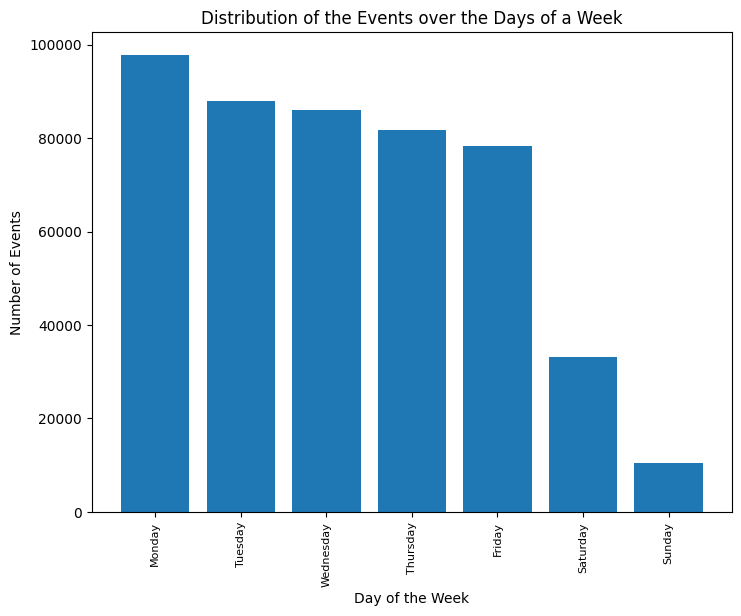

In [63]:
pm4py.view_events_distribution_graph(renamed_log, distr_type="days_week")

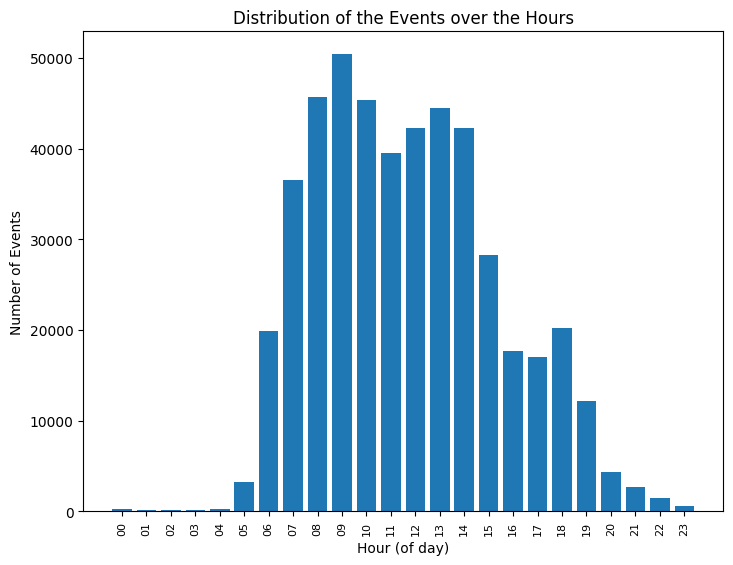

In [64]:
pm4py.view_events_distribution_graph(renamed_log, distr_type="hours")

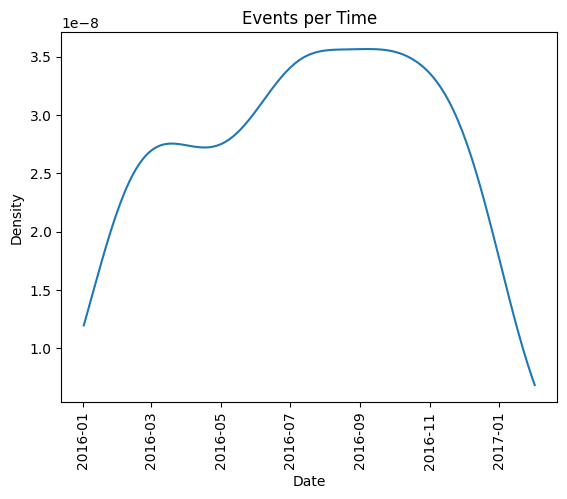

In [65]:
pm4py.view_events_per_time_graph(renamed_log)

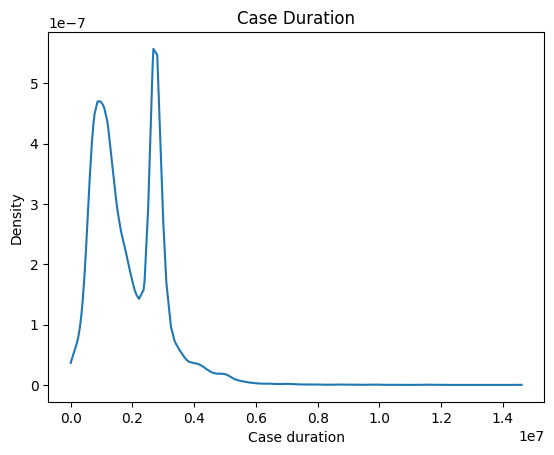

In [66]:
pm4py.view_case_duration_graph(renamed_log)